# Sentiment Analysis of Football-Related Tweets:

## A Comparative Study Between Cristiano Ronaldo and Lionel Messi Fan Discourse

## 1. Initial Setup & Data Acquisition

In this section, we prepare the environment and retrieve the dataset that will be used throughout the project.

First, we import all the required libraries for data processing, visualization, and machine learning. These include standard tools such as `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualization, and several models from `scikit-learn` for later classification tasks. Additionally, natural language processing libraries such as `nltk` and `spacy` are included to support text preprocessing and sentiment analysis.

Warnings are suppressed to ensure a cleaner output, particularly those related to model convergence during training.

In [1]:
# Initial imports for data processing, sentiment analysis, visualization...
import os
import re
import nltk
import spacy
import warnings
import kagglehub
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

warnings.filterwarnings('ignore')  # Suppress convergence warnings

# !pip install tqdm
# !pip install spacy
# !python -m spacy download en_core_web_sm

Next, we download the dataset using `KaggleHub`, which provides a convenient way to access Kaggle datasets directly from the notebook environment.

After downloading, we explore the directory structure to understand the available files and resources. This step is important to identify which datasets are relevant for the analysis and how they are organized.

In [2]:
# Download dataset from KaggleHub - stores in local cache

# Download latest version
path = kagglehub.dataset_download("ibrahimserouis99/twitter-sentiment-analysis-and-word-embeddings")

print("Dataset path:", path)

# Explore dataset directory structure to identify available files
# List all files and folders inside the dataset directory
for root, dirs, files in os.walk(path):
    print(f"\nDirectory: {root}")

    if dirs:
        print(" Subdirectories:")
        for d in dirs:
            print("  -", d)

    if files:
        print(" Files:")
        for f in files:
            print("  -", f)

Using Colab cache for faster access to the 'twitter-sentiment-analysis-and-word-embeddings' dataset.
Dataset path: /kaggle/input/twitter-sentiment-analysis-and-word-embeddings

Directory: /kaggle/input/twitter-sentiment-analysis-and-word-embeddings
 Subdirectories:
  - TSA_model_v4
  - Dataset
  - Visualization
 Files:
  - messi_final.csv
  - ronaldo_tweets.csv
  - Predictions_ronaldo.csv
  - ronaldo_final.csv
  - Cleaned_messi_tweets.csv
  - Predictions_messi.csv
  - messi_tweets.csv
  - Cleaned_ronaldo_tweets.csv

Directory: /kaggle/input/twitter-sentiment-analysis-and-word-embeddings/TSA_model_v4
 Subdirectories:
  - variables
 Files:
  - saved_model.pb

Directory: /kaggle/input/twitter-sentiment-analysis-and-word-embeddings/TSA_model_v4/variables
 Files:
  - variables.index
  - variables.data-00000-of-00001

Directory: /kaggle/input/twitter-sentiment-analysis-and-word-embeddings/Dataset
 Subdirectories:
  - Dataset

Directory: /kaggle/input/twitter-sentiment-analysis-and-word-embed

From the directory exploration, we observe that the dataset includes multiple components:

- Raw and cleaned tweet datasets for both Ronaldo and Messi
- Precomputed prediction files
- Training and test datasets for model development
- Word embeddings and a pretrained deep learning model

This variety of files suggests that the dataset is intended for both exploratory analysis and machine learning experimentation.

In [3]:
# Collect all CSV files from dataset directory
data_files = []

for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith((".csv", ".json")):
            full_path = os.path.join(root, f)
            data_files.append(full_path)

print("Data files found:")
for file in data_files:
    print(file)

Data files found:
/kaggle/input/twitter-sentiment-analysis-and-word-embeddings/messi_final.csv
/kaggle/input/twitter-sentiment-analysis-and-word-embeddings/ronaldo_tweets.csv
/kaggle/input/twitter-sentiment-analysis-and-word-embeddings/Predictions_ronaldo.csv
/kaggle/input/twitter-sentiment-analysis-and-word-embeddings/ronaldo_final.csv
/kaggle/input/twitter-sentiment-analysis-and-word-embeddings/Cleaned_messi_tweets.csv
/kaggle/input/twitter-sentiment-analysis-and-word-embeddings/Predictions_messi.csv
/kaggle/input/twitter-sentiment-analysis-and-word-embeddings/messi_tweets.csv
/kaggle/input/twitter-sentiment-analysis-and-word-embeddings/Cleaned_ronaldo_tweets.csv
/kaggle/input/twitter-sentiment-analysis-and-word-embeddings/Dataset/Dataset/training_dataset.csv
/kaggle/input/twitter-sentiment-analysis-and-word-embeddings/Dataset/Dataset/test_dataset.csv


To streamline data handling, we programmatically collect all relevant `.csv` files within the dataset directory. This approach improves reproducibility and avoids hardcoding file paths, making the notebook more flexible to structural changes in the dataset.

In [4]:
# Extract file paths for Ronaldo and Messi tweet datasets
ronaldo_path = [f for f in data_files if "ronaldo_tweets.csv" in f and "Cleaned" not in f][0]
messi_path = [f for f in data_files if "messi_tweets.csv" in f and "Cleaned" not in f][0]

print("Ronaldo dataset:", ronaldo_path)
print("Messi dataset:", messi_path)

Ronaldo dataset: /kaggle/input/twitter-sentiment-analysis-and-word-embeddings/ronaldo_tweets.csv
Messi dataset: /kaggle/input/twitter-sentiment-analysis-and-word-embeddings/messi_tweets.csv


Finally, we extract the specific datasets that will be used in the analysis: tweets related to Cristiano Ronaldo and Lionel Messi.

These datasets will serve as the foundation for the sentiment analysis task, enabling a comparative study between both players.

## 2. Exploratory Data Analysis (EDA)

In this section, we perform an initial exploration and cleaning of the dataset in order to ensure data quality before applying any machine learning techniques.

We begin by loading the tweet datasets for both players into pandas DataFrames. To facilitate comparative analysis, a new categorical feature (`player`) is introduced, allowing us to distinguish between tweets related to each player.

Finally, both datasets are merged into a single unified DataFrame, which will be used throughout the rest of the analysis.

In [5]:
# Load datasets into DataFrames for analysis
df_ronaldo = pd.read_csv(ronaldo_path)  # Load Ronaldo tweets
df_messi = pd.read_csv(messi_path)      # Load Messi tweets

print("\nRonaldo shape:", df_ronaldo.shape)  # (rows, columns)
print("Messi shape:", df_messi.shape)

# Add player identifier and combine both datasets
df_ronaldo["player"] = "ronaldo"  # Label Ronaldo rows
df_messi["player"] = "messi"      # Label Messi rows

# Combine datasets
df = pd.concat([df_ronaldo, df_messi], ignore_index=True)  # Vertically stack

print("\nCombined dataset shape:", df.shape)

# Inspect dataset structure and content
print("\nColumns:")
print(df.columns)  # Show all feature names

print("\nFirst rows:")
df.head()  # Preview first 5 records


Ronaldo shape: (502635, 10)
Messi shape: (502785, 10)

Combined dataset shape: (1005420, 11)

Columns:
Index(['tweet_id', 'author_id', 'content', 'lang', 'date', 'source', 'geo',
       'retweet_count', 'like_count', 'quote_count', 'player'],
      dtype='object')

First rows:


,tweet_id,author_id,content,lang,date,source,geo,retweet_count,like_count,quote_count,player
0,1554369938630103040,1413800950846922757,@UnderConstruc11 @fergiesperch @ArtemisPhoenix...,en,2022-08-02T07:34:06.000Z,Twitter for Android,NaN,0,0,0,ronaldo
1,1554369912428167170,1331632873338793986,Man Utd transfer news LIVE: Frenkie de Jong FI...,en,2022-08-02T07:34:00.000Z,Publer.io,NaN,0,0,0,ronaldo
2,1554369829414502400,1193232041959186434,@sportbible R9 and Ronaldinho make me smile wh...,en,2022-08-02T07:33:40.000Z,Twitter for iPhone,NaN,0,0,0,ronaldo
3,1554369821432840192,727241246465527809,@Joshua_Ubeku Ronaldo was in the best champion...,en,2022-08-02T07:33:38.000Z,Twitter for Android,NaN,0,0,0,ronaldo
4,1554369806714867712,1324146514495741952,“From Cristiano Ronaldo’s point of view it is ...,en,2022-08-02T07:33:35.000Z,WordPress.com,NaN,0,0,0,ronaldo


The combined dataset contains over one million tweets, with a balanced number of samples for both players. The structure includes metadata such as tweet identifiers, author information, engagement metrics (likes, retweets, quotes), and the textual content itself.

At this stage, the `content` column is identified as the key feature for the sentiment analysis task, while the remaining variables may be useful for complementary analysis or feature engineering.

In [6]:
# Check language distribution in dataset
print(df["lang"].value_counts())  # Count tweets per language

# Filter to keep only English tweets for sentiment analysis
df = df[df["lang"] == "en"]  # Boolean indexing

print("\nShape after language filter:", df.shape)

lang
en                     1005410
lang                         2
Twitter for Android          1
Twitter for iPhone           1
JustFor.Fans                 1
Name: count, dtype: int64

Shape after language filter: (1005410, 11)


Since sentiment analysis models are typically language-dependent, we restrict the dataset to English tweets only.

The results show that the dataset is already overwhelmingly composed of English tweets, with only a negligible number of entries in other languages or mislabeled categories. Therefore, this filtering step has minimal impact on the dataset size while ensuring consistency in the analysis.

In [7]:
# Remove duplicate tweets based on content
before = df.shape[0]  # Row count before deduplication

df = df.drop_duplicates(subset="content")  # Keep first occurrence only

after = df.shape[0]   # Row count after deduplication

print("Removed duplicates:", before - after)
print("New shape:", df.shape)

# Handle missing text values
print("Empty texts:", df["content"].isnull().sum())  # Count NaN values

df = df[df["content"].notnull()]  # Remove rows with null content

Removed duplicates: 135141
New shape: (870269, 11)
Empty texts: 0


Next, we remove duplicate tweets based on their textual content. This step is crucial to prevent bias in the analysis, as repeated messages could disproportionately influence both exploratory insights and model training.

A significant number of duplicates are detected and removed, indicating that the dataset contains a considerable amount of repeated or highly similar content.

We also verify the presence of missing values in the text field. Since no null values are found, no additional imputation is required at this stage.

In [8]:
# Create feature for tweet length (characters)
df["text_length"] = df["content"].apply(len)  # Apply len() to each text

print(df["text_length"].describe())  # Statistics: mean, min, max, etc.

# Remove very short tweets (likely noise or missing data)
df = df[df["text_length"] > 20]  # Keep tweets longer than 20 chars

print("\nShape after length filter:", df.shape)

count    870269.000000
mean        131.421205
std          80.780220
min           6.000000
25%          68.000000
50%         109.000000
75%         179.000000
max         962.000000
Name: text_length, dtype: float64

Shape after length filter: (863750, 12)


To further refine the dataset, we introduce a new feature representing the length of each tweet in characters. This allows us to analyze the distribution of text lengths and identify potentially noisy samples.

Very short tweets (less than 20 characters) are removed, as they often lack meaningful semantic information and may introduce noise into the sentiment analysis task. The descriptive statistics show a wide distribution of tweet lengths, with most tweets containing sufficient textual content for analysis.

player
ronaldo    491698
messi      372052
Name: count, dtype: int64


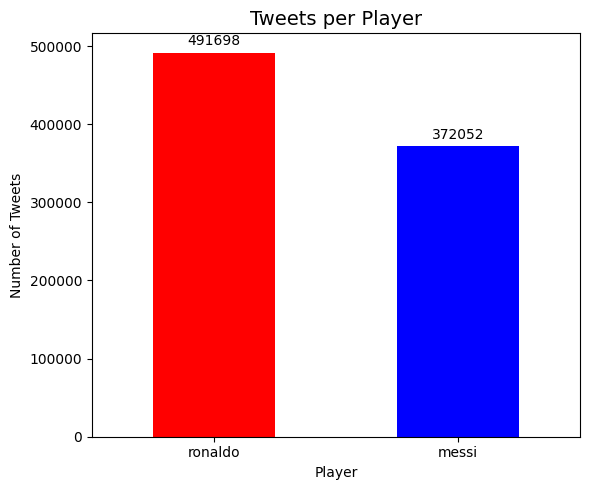

In [9]:
# Verify balanced representation of both players
print(df["player"].value_counts())  # Count Ronaldo vs Messi tweets

# Visualize class balance after filtering
plt.figure(figsize=(6,5))
ax = df["player"].value_counts().plot(kind="bar", color=["red", "blue"])
ax.bar_label(ax.containers[0], label_type='edge', padding=3)
plt.title("Tweets per Player", fontsize=14)
plt.xlabel("Player")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Finally, we examine the distribution of tweets between both players after all preprocessing steps.

Although the dataset was initially balanced, a slight imbalance is introduced after filtering, with a higher number of tweets associated with Cristiano Ronaldo. However, this imbalance is not severe and is unlikely to significantly affect model performance, especially when using robust evaluation techniques.

## 3. Methodology - NLP Preprocessing

### 3.1. Text Cleaning & Tokenization

In this section, we apply a Natural Language Processing (NLP) pipeline to transform raw tweet text into a structured format suitable for analysis and machine learning models.

We leverage the `spaCy` library for efficient text processing. To improve performance when handling large datasets, unnecessary components such as dependency parsing and named entity recognition are disabled, focusing only on tokenization and lemmatization.

In [10]:
# Load spaCy with disabled components for better performance on large datasets
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner', 'entity_linker', 'entity_ruler'])

The first step consists of basic text cleaning. This includes converting all text to lowercase, removing URLs, mentions, and special characters, and keeping only alphabetic characters.

This normalization step reduces noise and ensures that similar words are treated consistently, which is essential for downstream tasks such as vectorization and sentiment analysis.

Additionally, a random sample of 100,000 tweets is extracted to speed up development and experimentation, while still maintaining a representative subset of the data.

In [11]:
# Basic text cleaning: lowercase, remove URLs, mentions, special chars
def basic_clean(text):
    text = text.lower()                     # Convert to lowercase
    text = re.sub(r"http\S+", "", text)     # Remove URLs (http, https)
    text = re.sub(r"@\w+", "", text)        # Remove @mentions
    text = re.sub(r"#", "", text)           # Remove # symbol but keep word
    text = re.sub(r"[^a-z\s]", "", text)    # Keep only letters and spaces
    return text

df["clean_text"] = df["content"].apply(basic_clean)  # Apply to all tweets

# Take 100k sample for faster processing during development
df_sample = df.sample(100000, random_state=16)  # random_state for reproducibility

In [12]:
# Advanced preprocessing: lemmatization, stopword removal, punctuation removal
def preprocess(text):
    doc = nlp(text)  # Process with spaCy pipeline

    tokens = []

    for token in doc:
        # Remove stopwords, punctuation, and short tokens (length <= 2)
        if token.is_stop or token.is_punct or len(token) <= 2:
            continue

        # Remove contraction artifacts (e.g., "n't" -> "not" handled by spaCy)
        # These lemmas appear from contractions like don't, I've, I'll
        if token.lemma_ in ["don", "ve", "ll"]:
            continue

        tokens.append(token.lemma_)  # Add lemmatized token

    return " ".join(tokens)  # Return space-separated string

# Show progress bar for large dataset
tqdm.pandas(desc="Processing tweets")

# Apply preprocessing with progress indicator
df_sample["processed_text"] = df_sample["clean_text"].progress_apply(preprocess)

Processing tweets: 100%|██████████| 100000/100000 [07:20<00:00, 227.08it/s]


We then apply a more advanced preprocessing pipeline using spaCy.

This step includes:
- Tokenization of the text
- Lemmatization to reduce words to their base form
- Removal of stopwords and punctuation
- Filtering of very short tokens and contraction artifacts

These transformations significantly reduce the dimensionality of the text while preserving its semantic meaning, which is crucial for improving model performance.

The use of a progress bar highlights the computational cost of this step, reinforcing the importance of working with a sample during development.

In [13]:
# Preview original vs processed text to verify cleaning worked
df_sample[["content", "processed_text"]].head(10)

,content,processed_text
337546,@Ghana_Ronaldo @sammynife Tell her you don’t grab,tell grab
860181,@johnaokane Two hattricks around complete dros...,hattrick complete dross incompetence highlight...
545158,@SaraFCBi @talkfcb_ A burofax won't solve anyt...,burofax solve see lionel messi barcelona bayer...
198623,@ESPNFC Why use Ronaldo for a stat he wasn’t i...,use ronaldo stat involve
878705,Fuck messi fc man😭😭😭😭 https://t.co/xpGkUaRkth,fuck messi man
860360,@Cristiano the 🐐… shove your #Messi’s up ye ar...,shove messis arsis
7358,@MikeLUHG2 Ronaldo is a glazer puppet as well ...,ronaldo glazer puppet address
146749,@Migas1893 We’re not that country that has *th...,country good player squad anymore sure histori...
383240,That looked like ManUtd Cricket Club. Barring ...,look like manutd cricket club bar ronaldo ddg ...
72567,@Afro_Specials Davido can't go with Ronaldo......,davido ronaldodavido messi


A manual inspection of the processed text confirms that the preprocessing pipeline is working as expected.

Irrelevant elements such as mentions, links, and special characters have been removed, and the remaining tokens are normalized and lemmatized. The resulting text is more compact and semantically meaningful, making it suitable for feature extraction.

### 3.2. Sentiment Analysis (VADER)

To perform sentiment analysis, we use the VADER (Valence Aware Dictionary and sEntiment Reasoner) model from NLTK, which is specifically designed for social media text.

VADER provides a compound sentiment score ranging from -1 (most negative) to +1 (most positive), capturing the overall sentiment polarity of each tweet.

In [14]:
# Download VADER lexicon (if not already downloaded)
nltk.download('vader_lexicon', quiet=True)  # quiet=True reduces output

# Initialize VADER sentiment analyzer (optimized for social media)
sia = SentimentIntensityAnalyzer()

# Calculate compound sentiment score (-1 = very negative, +1 = very positive)
df_sample["sentiment_score"] = df_sample["clean_text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]) # Extract compound score

# Convert continuous sentiment score to categorical labels
def get_sentiment_label(score):
    if score > 0.05:      # Threshold for positive
        return "positive"
    elif score < -0.05:   # Threshold for negative
        return "negative"
    else:                  # Neutral zone: [-0.05, 0.05]
        return "neutral"

df_sample["sentiment"] = df_sample["sentiment_score"].apply(get_sentiment_label)

The continuous sentiment score is then converted into categorical labels (positive, neutral, negative) using standard threshold values.

This transformation simplifies interpretation and enables classification-based analysis, while still retaining the original score for more granular insights.

In [15]:
# Verify sentiment assignment on sample tweets
df_sample[["content", "sentiment", "sentiment_score"]].head(10)

,content,sentiment,sentiment_score
337546,@Ghana_Ronaldo @sammynife Tell her you don’t grab,neutral,0.0000
860181,@johnaokane Two hattricks around complete dros...,negative,-0.2263
545158,@SaraFCBi @talkfcb_ A burofax won't solve anyt...,neutral,0.0279
198623,@ESPNFC Why use Ronaldo for a stat he wasn’t i...,neutral,0.0000
878705,Fuck messi fc man😭😭😭😭 https://t.co/xpGkUaRkth,negative,-0.5423
860360,@Cristiano the 🐐… shove your #Messi’s up ye ar...,neutral,0.0000
7358,@MikeLUHG2 Ronaldo is a glazer puppet as well ...,positive,0.1406
146749,@Migas1893 We’re not that country that has *th...,positive,0.9127
383240,That looked like ManUtd Cricket Club. Barring ...,positive,0.8772
72567,@Afro_Specials Davido can't go with Ronaldo......,neutral,0.0000


,count
sentiment,
positive,46426
neutral,30051
negative,23523


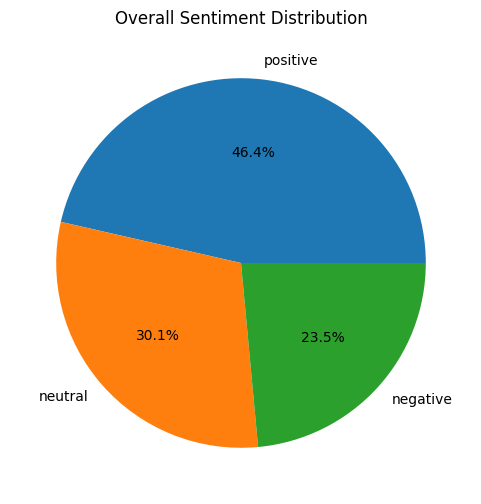

In [16]:
# Check overall sentiment distribution
display(df_sample["sentiment"].value_counts())  # Show raw counts

# Visualize sentiment distribution (pie chart)
df_sample["sentiment"].value_counts().plot(kind="pie", autopct='%1.1f%%', figsize=(6,6))
plt.title("Overall Sentiment Distribution")
plt.ylabel("")  # Remove y-label for cleaner look
plt.show()

The overall sentiment distribution shows that most tweets are classified as positive, followed by neutral and negative sentiments.

This suggests a general positive bias in the dataset, which is common in sports-related discussions where fans tend to express support and admiration.

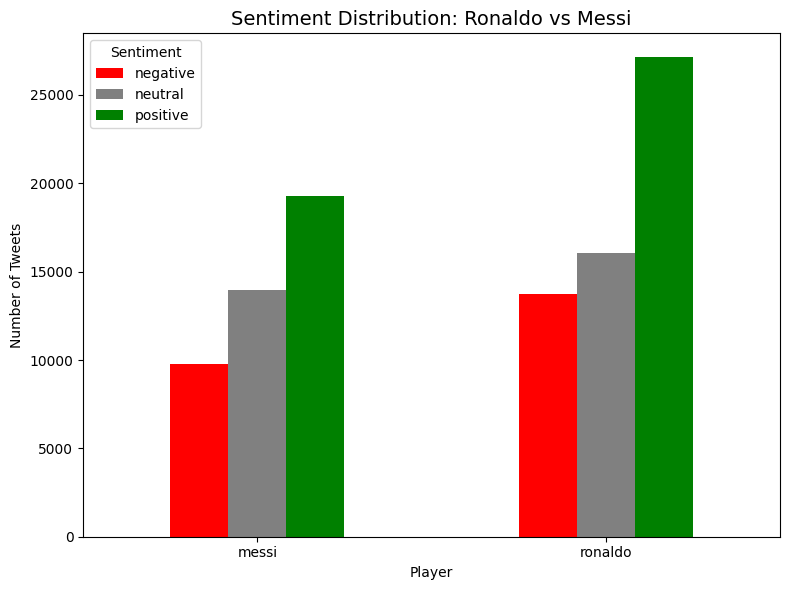

In [17]:
# Compare sentiment proportions between Ronaldo and Messi
sentiment_counts = df_sample.groupby(["player", "sentiment"]).size().unstack()

sentiment_counts.plot(kind="bar", figsize=(8, 6), color=["red", "gray", "green"])
plt.title("Sentiment Distribution: Ronaldo vs Messi", fontsize=14)
plt.xlabel("Player")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

When comparing sentiment distributions between players, both exhibit similar patterns, although slight differences can be observed.

Cristiano Ronaldo shows a marginally higher proportion of positive tweets, while Lionel Messi has a slightly higher proportion of neutral sentiment. These differences, although small, may reflect variations in public perception or fan engagement.

In [18]:
# Sentiment proportions between Ronaldo and Messi
display(df_sample.groupby("player")["sentiment"].value_counts(normalize=True))

# Average sentiment score per player (numeric, more granular than labels)
display(df_sample.groupby("player")["sentiment_score"].mean())

player   sentiment
messi    positive     0.448112
         neutral      0.324430
         negative     0.227459
ronaldo  positive     0.476469
         neutral      0.282425
         negative     0.241106
Name: proportion, dtype: float64

,sentiment_score
player,
messi,0.131254
ronaldo,0.143567


The average sentiment score per player provides a more granular perspective than categorical labels.

Both players have positive average sentiment scores, reinforcing the idea that the overall discourse is favorable. Ronaldo shows a slightly higher average score, which is consistent with the distribution observed earlier.

### 3.3. Advanced Analysis (Engagement, Words, Time)

Beyond sentiment classification, we explore additional patterns related to user engagement and textual content.

In [19]:
# Convert engagement metrics to numeric
df_sample["like_count"] = pd.to_numeric(df_sample["like_count"], errors="coerce")  # NaN if fails
df_sample["retweet_count"] = pd.to_numeric(df_sample["retweet_count"], errors="coerce")

# Average likes/retweets per sentiment category
df_sample.groupby("sentiment")[["like_count", "retweet_count"]].mean()

,like_count,retweet_count
sentiment,,
negative,15.792671,1.338095
neutral,33.102293,2.586436
positive,32.003446,2.750205


Analyzing engagement metrics reveals that neutral and positive tweets tend to receive more likes and retweets on average than negative ones.

This may indicate that positive or neutral content is more widely shared or better received by the audience, while negative tweets generate less interaction.

In [20]:
# Most common words across ALL tweets (overall vocabulary)
all_words = " ".join(df_sample["processed_text"]).split()  # Flatten all tokens
Counter(all_words).most_common(20)  # Top 20 frequent words

[('messi', 54416),
 ('ronaldo', 52780),
 ('goal', 12718),
 ('player', 9651),
 ('play', 8403),
 ('like', 8162),
 ('win', 7591),
 ('good', 7471),
 ('season', 7368),
 ('team', 7293),
 ('score', 7286),
 ('fan', 7144),
 ('cristiano', 6840),
 ('league', 6430),
 ('well', 6051),
 ('man', 5983),
 ('year', 4828),
 ('game', 4715),
 ('time', 4638),
 ('football', 4468)]

The most frequent words across all tweets highlight the central topics of discussion, with terms such as "messi", "ronaldo", "goal", and "player" dominating the vocabulary.

This confirms that the dataset is strongly focused on football-related conversations, with an emphasis on performance, matches, and fan opinions.

In [21]:
# Compare positive vs negative vocabulary
positive_words = " ".join(df_sample[df_sample["sentiment"] == "positive"]["processed_text"]).split()
negative_words = " ".join(df_sample[df_sample["sentiment"] == "negative"]["processed_text"]).split()

print("Top positive words:")
print(Counter(positive_words).most_common(15))

print("\nTop negative words:")
print(Counter(negative_words).most_common(15))

Top positive words:
[('messi', 26500), ('ronaldo', 25984), ('goal', 6602), ('play', 6600), ('win', 6423), ('good', 6416), ('player', 6322), ('like', 6224), ('well', 5321), ('team', 4316), ('season', 4174), ('fan', 4061), ('league', 4022), ('cristiano', 3620), ('score', 3617)]

Top negative words:
[('ronaldo', 13259), ('messi', 12379), ('goal', 2615), ('fan', 2220), ('player', 2135), ('team', 1984), ('season', 1845), ('man', 1756), ('score', 1756), ('like', 1739), ('play', 1629), ('bad', 1465), ('cristiano', 1351), ('league', 1326), ('say', 1310)]


A comparison between positive and negative vocabularies shows a high overlap in commonly used words, suggesting that sentiment is often conveyed through context rather than distinct terminology.

However, certain words such as "good", "win", and "well" appear more frequently in positive tweets, while terms like "bad" are more associated with negative sentiment.

This observation highlights the challenges of sentiment analysis in sports discussions, where similar topics can be expressed with different emotional tones.

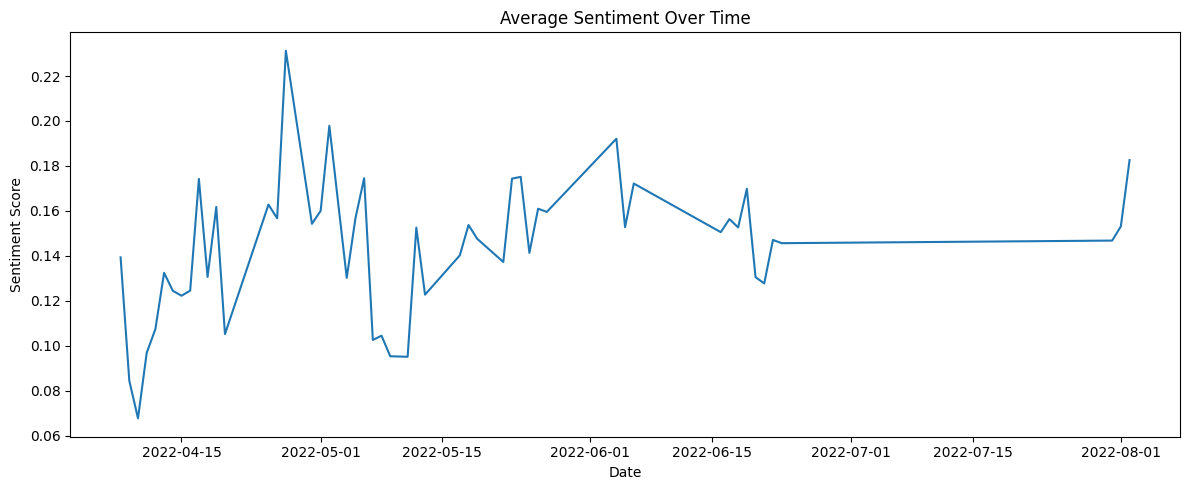

In [22]:
# Time series analysis: sentiment evolution over time
# Convert date column to datetime format
df_sample["date"] = pd.to_datetime(df_sample["date"])

# Extract just the date part (without time)
df_sample["day"] = df_sample["date"].dt.date

# Average sentiment score per day
daily_sentiment = df_sample.groupby("day")["sentiment_score"].mean()

# Plot
daily_sentiment.plot(figsize=(12,5))

plt.title("Average Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.tight_layout()
plt.show()

The time series analysis of the average sentiment reveals a generally stable and positive trend over time.

Although some fluctuations are observed, sentiment scores remain consistently above zero, indicating that the overall perception in tweets is positive throughout the analyzed period. Occasional peaks and drops may correspond to specific events or discussions, but no extreme sentiment shifts are detected.

Interestingly, the latter part of the timeline shows a smoother trend. This may be due to fewer data points per day or aggregation effects, which reduce variability in the average sentiment.

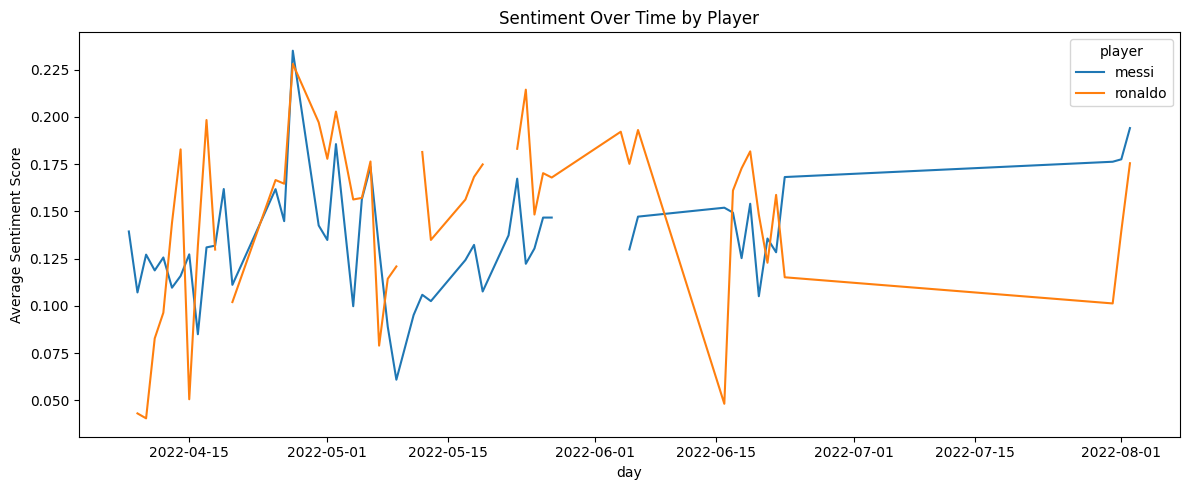

In [23]:
# Compare sentiment trends: Ronaldo vs Messi over time
df_sample.groupby(["day", "player"])["sentiment_score"].mean().unstack().plot(figsize=(12,5))
plt.title("Sentiment Over Time by Player")
plt.ylabel("Average Sentiment Score")
plt.tight_layout()
plt.show()

When comparing sentiment trends between players, both Ronaldo and Messi exhibit similar temporal patterns, reinforcing the idea that public sentiment towards them evolves in parallel.

However, some differences can be observed:
- Ronaldo's sentiment appears slightly more volatile, with sharper peaks and drops
- Messi's sentiment is comparatively more stable over time

Despite these variations, both players maintain predominantly positive sentiment across the entire period.

These findings suggest that, while short-term fluctuations exist, overall public perception of both players remains consistently favorable.

## 4. Experimentation - Vectorization & Modeling

In this section, we transform the preprocessed text into numerical features and train several machine learning models to perform sentiment classification.

Since machine learning algorithms require numerical input, we apply the TF-IDF (Term Frequency-Inverse Document Frequency) technique, which converts text into a weighted feature representation based on word importance.

In [24]:
# Convert text to numerical features using TF-IDF (Term Frequency-Inverse Document Frequency)

# Initialize vectorizer with optimized parameters for tweets
tfidf = TfidfVectorizer(
    max_features=5000,          # Limit vocabulary size (avoid memory issues)
    ngram_range=(1, 2),         # Use unigrams and bigrams (captures phrases like "not good")
    stop_words="english")       # Remove common English words (the, and, etc.)

# Raw text and target variable (vectorization happens after the split)
X_raw = df_sample["processed_text"]  # Raw text (not yet vectorized)
y = df_sample["sentiment"]           # positive / neutral / negative

print(f"Total samples: {X_raw.shape[0]}")
print(f"Target shape: {y.shape}")

Total samples: 100000
Target shape: (100000,)


The TF-IDF vectorizer is configured with several optimizations tailored to short social media texts:

- A maximum vocabulary size of 5,000 features to control dimensionality and computational cost
- Inclusion of both unigrams and bigrams to capture contextual information (e.g., "not good")
- Removal of common English stopwords to reduce noise

The resulting feature matrix is sparse and high-dimensional, representing each tweet as a vector of term importance scores.

In [25]:
# Split data into training and testing sets (stratify ensures balanced classes)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,          # 20% for testing, 80% for training
    random_state=16,        # Reproducible results
    stratify=y)             # Preserve sentiment class distribution

# Fit vectorizer only on training data, then transform both sets separately
# This prevents vocabulary leakage from the test set into the feature space
X_train = tfidf.fit_transform(X_train_raw)  # Learn vocabulary + transform
X_test  = tfidf.transform(X_test_raw)       # Transform only (no fitting)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Feature matrix shape: {X_train.shape}")
print("\nTraining sentiment distribution:")
print(y_train.value_counts(normalize=True))  # Verify stratification worked

Training set size: 80000 samples
Testing set size: 20000 samples
Feature matrix shape: (80000, 5000)

Training sentiment distribution:
sentiment
positive    0.464263
neutral     0.300513
negative    0.235225
Name: proportion, dtype: float64


The dataset is split into training and testing sets using an 80/20 ratio.

Stratified sampling is applied to preserve the original class distribution across both sets, ensuring that the evaluation metrics are reliable and not biased by class imbalance.

To evaluate different modeling approaches, we train four commonly used classification algorithms:

- Support Vector Machine (SVM)
- Naive Bayes
- Logistic Regression
- Random Forest

These models represent a diverse set of techniques, ranging from probabilistic methods to linear classifiers and ensemble models, allowing for a comprehensive comparison.

In [26]:
# Define 4 models with optimized parameters
models = {
    "SVM": LinearSVC(random_state=16, max_iter=3000, class_weight='balanced'),
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(random_state=16, max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=16, n_jobs=-1)}

# 5-fold stratified cross-validation (preserves class distribution)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=16)

print("5-FOLD CROSS-VALIDATION RESULTS (on training set)")

cv_results = {}

for name, model in models.items():
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    cv_results[name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores}

    print(f"\n{name}:")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Fold scores: {cv_scores}")

# Train all models on full training set and evaluate on test set
print("\nTEST SET EVALUATION (trained on full training set)")

test_results = {}

for name, model in models.items():
    # Train on full training set
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')

    test_results[name] = {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'predictions': y_pred,
        'model': model}

    print(f"\n{name}:")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  Macro F1-Score: {macro_f1:.4f}")
    print(f"  Weighted F1-Score: {weighted_f1:.4f}")

5-FOLD CROSS-VALIDATION RESULTS (on training set)

SVM:
  CV Accuracy: 0.7962 (+/- 0.0017)
  Fold scores: [0.794     0.797375  0.7983125 0.7945625 0.7968125]

Naive Bayes:
  CV Accuracy: 0.6992 (+/- 0.0015)
  Fold scores: [0.700125  0.6998125 0.696125  0.7000625 0.6996875]

Logistic Regression:
  CV Accuracy: 0.7874 (+/- 0.0028)
  Fold scores: [0.78825   0.7850625 0.7925    0.785625  0.7855625]

Random Forest:
  CV Accuracy: 0.7615 (+/- 0.0032)
  Fold scores: [0.764     0.7606875 0.76625   0.758375  0.75825  ]

TEST SET EVALUATION (trained on full training set)

SVM:
  Test Accuracy: 0.8046
  Macro F1-Score: 0.7914
  Weighted F1-Score: 0.8036

Naive Bayes:
  Test Accuracy: 0.7058
  Macro F1-Score: 0.6775
  Weighted F1-Score: 0.6964

Logistic Regression:
  Test Accuracy: 0.7956
  Macro F1-Score: 0.7850
  Weighted F1-Score: 0.7957

Random Forest:
  Test Accuracy: 0.7693
  Macro F1-Score: 0.7392
  Weighted F1-Score: 0.7603


The results from cross-validation and test evaluation reveal several important insights.

SVM achieves the best overall performance, both in cross-validation and on the test set, indicating strong generalization capability. Logistic Regression also performs competitively, slightly below SVM but still robust.

Naive Bayes shows significantly lower performance, likely due to its simplifying independence assumptions, which may not hold in natural language data. Random Forest performs moderately well but does not outperform linear models, possibly due to the high dimensionality and sparsity of TF-IDF features.

The low standard deviation in cross-validation scores suggests stable model performance across different data splits.

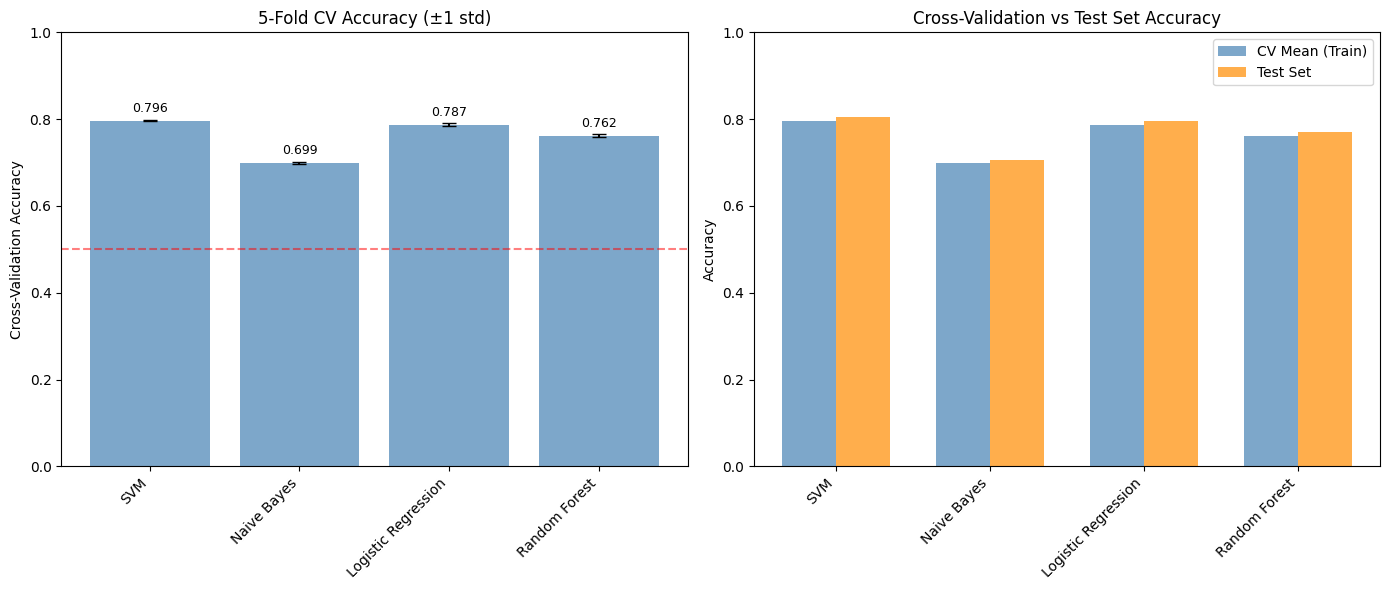

SUMMARY TABLE - ALL MODELS
              Model  CV_Accuracy   CV_Std  Test_Accuracy  Macro_F1
                SVM     0.796212 0.001658        0.80460  0.791365
        Naive Bayes     0.699163 0.001527        0.70585  0.677521
Logistic Regression     0.787400 0.002783        0.79560  0.784952
      Random Forest     0.761513 0.003156        0.76930  0.739190

 BEST MODEL: SVM
   Test Accuracy: 0.8046


In [27]:
# Visual comparison of all 4 models

# Prepare data for plotting
model_names = list(cv_results.keys())
cv_means = [cv_results[m]['mean'] for m in model_names]
cv_stds = [cv_results[m]['std'] for m in model_names]
test_accs = [test_results[m]['accuracy'] for m in model_names]

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Cross-validation results (with error bars)
x_pos = np.arange(len(model_names))
axes[0].bar(x_pos, cv_means, yerr=cv_stds, capsize=5, color='steelblue', alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].set_ylabel("Cross-Validation Accuracy")
axes[0].set_title("5-Fold CV Accuracy (±1 std)")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

# Add value labels
for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    axes[0].text(i, mean + 0.02, f'{mean:.3f}', ha='center', fontsize=9)

# Subplot 2: Train vs Test comparison
x_pos = np.arange(len(model_names))
width = 0.35
axes[1].bar(x_pos - width/2, cv_means, width, label='CV Mean (Train)', color='steelblue', alpha=0.7)
axes[1].bar(x_pos + width/2, test_accs, width, label='Test Set', color='darkorange', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Cross-Validation vs Test Set Accuracy")
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Create results DataFrame for easy viewing
results_df = pd.DataFrame({
    'Model': model_names,
    'CV_Accuracy': [cv_results[m]['mean'] for m in model_names],
    'CV_Std': [cv_results[m]['std'] for m in model_names],
    'Test_Accuracy': [test_results[m]['accuracy'] for m in model_names],
    'Macro_F1': [test_results[m]['macro_f1'] for m in model_names]})

print("SUMMARY TABLE - ALL MODELS")
print(results_df.to_string(index=False))

# Identify best model
best_model_name = results_df.loc[results_df['Test_Accuracy'].idxmax(), 'Model']
best_model = test_results[best_model_name]['model']
best_predictions = test_results[best_model_name]['predictions']

print(f"\n BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {results_df['Test_Accuracy'].max():.4f}")

The visual comparison confirms that the models do not suffer from significant overfitting, as the cross-validation and test accuracies are closely aligned.

SVM is selected as the best-performing model, achieving the highest test accuracy and strong F1-scores, making it the most suitable choice for this sentiment classification task.

Overall, these results highlight the effectiveness of linear models when combined with TF-IDF features in text classification problems.

## 5. Results & Insights

In this final section, we analyze the performance of the best-performing model and extract key insights from both the quantitative results and the data visualizations.

The goal is not only to evaluate model accuracy, but also to understand its strengths, limitations, and the patterns present in the dataset.

BEST MODEL DETAILED REPORT: SVM

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.68      0.71      4705
     neutral       0.76      0.91      0.83      6010
    positive       0.87      0.80      0.83      9285

    accuracy                           0.80     20000
   macro avg       0.79      0.80      0.79     20000
weighted avg       0.81      0.80      0.80     20000



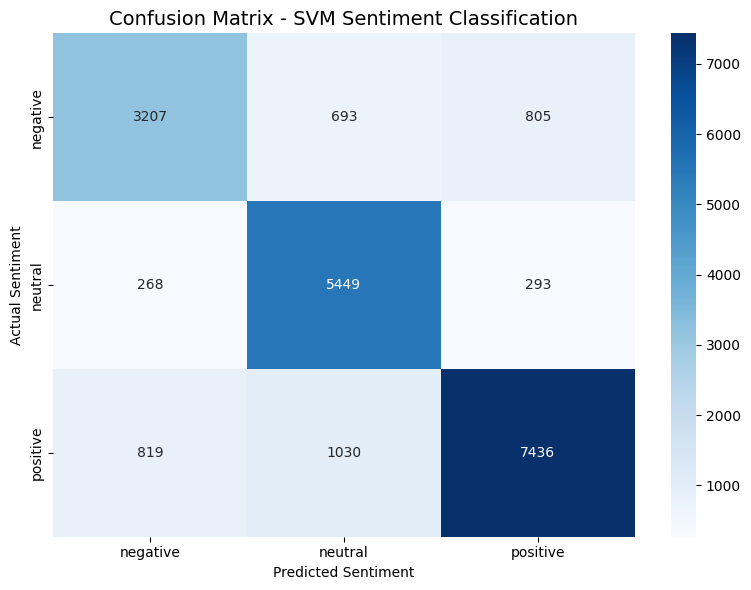


Additional Metrics (Macro Average):
  Precision: 0.7927
  Recall: 0.7964
  F1-Score: 0.7914


In [28]:
# Generate detailed performance metrics for the BEST model only
print(f"BEST MODEL DETAILED REPORT: {best_model_name}")

# Classification report (precision, recall, f1-score per class)
print("\nClassification Report:")
print(classification_report(y_test, best_predictions, target_names=["negative", "neutral", "positive"]))

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.title(f"Confusion Matrix - {best_model_name} Sentiment Classification", fontsize=14)
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

# Calculate additional metrics
precision_macro = precision_score(y_test, best_predictions, average='macro')
recall_macro = recall_score(y_test, best_predictions, average='macro')

print(f"\nAdditional Metrics (Macro Average):")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall: {recall_macro:.4f}")
print(f"  F1-Score: {f1_score(y_test, best_predictions, average='macro'):.4f}")

The detailed evaluation of the best model (SVM) shows strong overall performance, with an accuracy of approximately 80% and balanced macro-averaged metrics.

From the classification report, we observe that:
- The model performs best on the **positive** class, achieving high precision and recall
- The **neutral** class also shows strong performance, particularly in recall
- The **negative** class is the most challenging, with lower recall compared to the other classes

The confusion matrix provides additional insight into these results. Most misclassifications occur between neighboring sentiment classes (e.g., negative vs neutral or neutral vs positive), which is expected given the inherent ambiguity of natural language.

This behavior suggests that the model captures general sentiment trends well, but struggles with borderline or context-dependent cases.

To complement the quantitative evaluation, we use several visualizations to better understand the dataset and model behavior.

These visualizations focus on three main aspects:
- The most relevant words associated with each player
- Differences in sentiment distribution between players
- The relationship between sentiment scores and players
- A final comparison of model performance

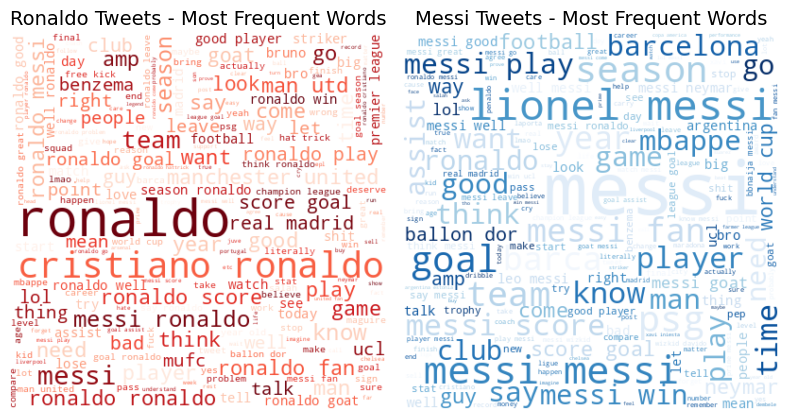

In [29]:
# Visualization 1: Word Clouds by Player

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 6))

# Word cloud for Ronaldo tweets
ronaldo_text = " ".join(df_sample[df_sample["player"] == "ronaldo"]["processed_text"])
wordcloud_ronaldo = WordCloud(width=400, height=400, background_color='white', colormap='Reds').generate(ronaldo_text)
axes[0].imshow(wordcloud_ronaldo, interpolation='bilinear')
axes[0].set_title("Ronaldo Tweets - Most Frequent Words", fontsize=14)
axes[0].axis('off')

# Word cloud for Messi tweets
messi_text = " ".join(df_sample[df_sample["player"] == "messi"]["processed_text"])
wordcloud_messi = WordCloud(width=400, height=400, background_color='white', colormap='Blues').generate(messi_text)
axes[1].imshow(wordcloud_messi, interpolation='bilinear')
axes[1].set_title("Messi Tweets - Most Frequent Words", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

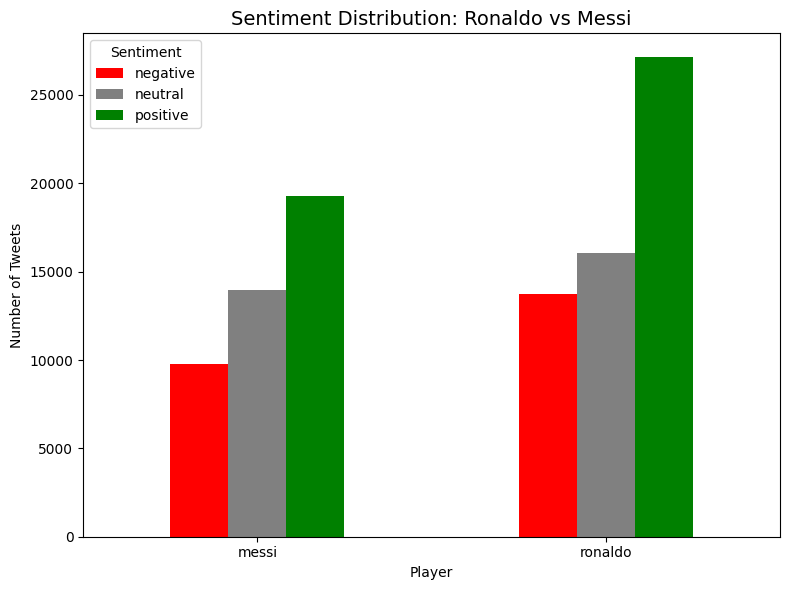

In [30]:
# Visualization 2: Comparative Sentiment Bar Chart (Grouped)
sentiment_counts = df_sample.groupby(["player", "sentiment"]).size().unstack()

sentiment_counts.plot(kind="bar", figsize=(8, 6), color=["red", "gray", "green"])
plt.title("Sentiment Distribution: Ronaldo vs Messi", fontsize=14)
plt.xlabel("Player")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

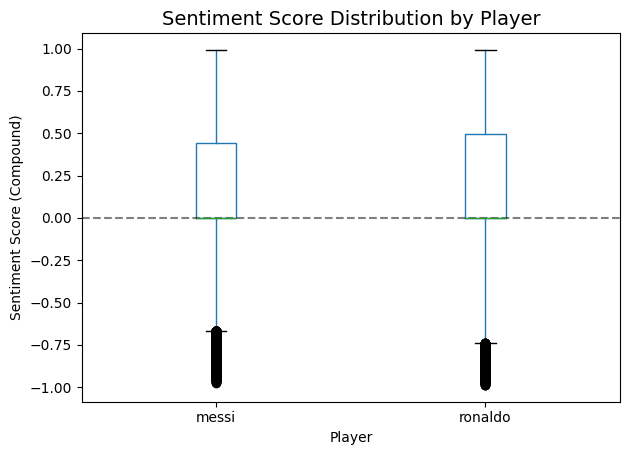

In [31]:
# Visualization 3: Sentiment Score Distribution (Boxplot)
plt.figure(figsize=(8, 6))
df_sample.boxplot(column="sentiment_score", by="player", grid=False)
plt.title("Sentiment Score Distribution by Player", fontsize=14)
plt.suptitle("")  # Remove automatic title
plt.xlabel("Player")
plt.ylabel("Sentiment Score (Compound)")
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)  # Neutral line
plt.tight_layout()
plt.show()

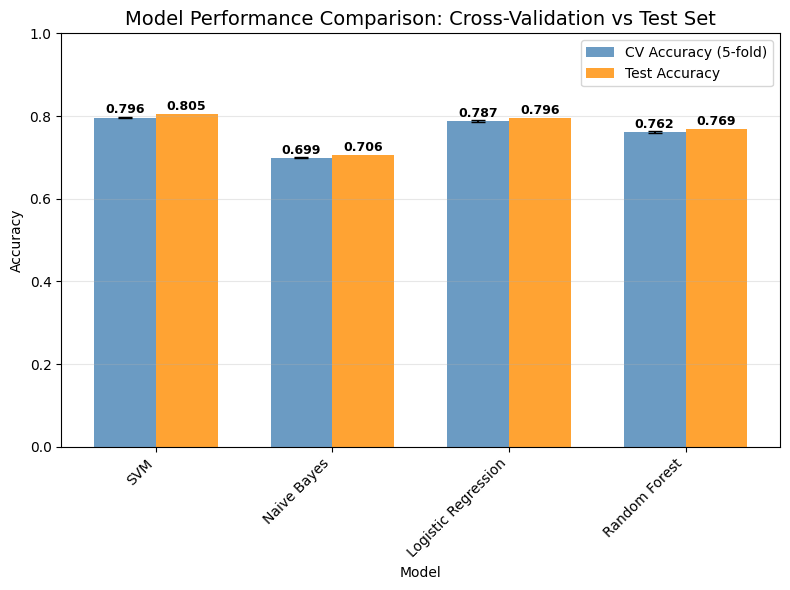

In [32]:
# Visualization 4: Final Model Comparison (All 4 models)
plt.figure(figsize=(8, 6))
x_pos = np.arange(len(model_names))
width = 0.35

bars1 = plt.bar(x_pos - width/2, cv_means, width, label='CV Accuracy (5-fold)', color='steelblue', alpha=0.8, yerr=cv_stds, capsize=5)
bars2 = plt.bar(x_pos + width/2, test_accs, width, label='Test Accuracy', color='darkorange', alpha=0.8)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison: Cross-Validation vs Test Set", fontsize=14)
plt.xticks(x_pos, model_names, rotation=45, ha='right')
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (cv_acc, test_acc) in enumerate(zip(cv_means, test_accs)):
    plt.text(i - width/2, cv_acc + 0.01, f'{cv_acc:.3f}', ha='center', fontsize=9, fontweight='bold')
    plt.text(i + width/2, test_acc + 0.01, f'{test_acc:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

The visual analysis provides several interesting insights.

Word clouds reveal that both players share a very similar vocabulary, dominated by football-related terms such as "goal", "player", and "team". This confirms that the discussions are highly centered around performance and matches rather than off-field topics.

The sentiment distribution highlights that while both players enjoy predominantly positive coverage, Ronaldo generates a higher overall volume of tweets across all categories. Despite this difference in scale, the ratio of positive to negative sentiment remains relatively consistent for both, confirming a general positive bias in the fan base.

The boxplot analysis reveals nearly identical sentiment distributions for both Messi and Ronaldo. Both players show a median score close to zero, but the distribution is slightly skewed toward positive territory. Notably, the presence of numerous outliers in the negative range suggests that while the general discourse is positive, there are specific clusters of highly critical or negative comments for both players.

Finally, the model comparison highlights SVM as the top performer, attaining a test accuracy of 80.46% and a macro-averaged F1-score of 0.7914 on the held-out test set, with a 5-fold cross-validation accuracy of 0.7962. The minimal gap between CV and test metrics suggests excellent generalization and a low risk of overfitting, further justifying SVM as the final choice for our sentiment analysis.

## 6. Conclusion

This project presented a complete pipeline for sentiment analysis on social media data, focusing on tweets related to Cristiano Ronaldo and Lionel Messi.

Starting from raw data acquisition, we performed exploratory data analysis and applied several preprocessing techniques to clean and normalize the textual data. Using Natural Language Processing methods such as tokenization and lemmatization, the text was transformed into a structured format suitable for machine learning models.

For feature extraction, TF-IDF vectorization was used to convert text into numerical representations. Several classification models were then trained and evaluated, including Support Vector Machines, Naive Bayes, Logistic Regression, and Random Forest.

Among them, the Support Vector Machine (SVM) achieved the best performance, reaching an accuracy of approximately 80% and strong F1-scores across all sentiment classes. The results demonstrate that linear models combined with TF-IDF features are highly effective for text classification tasks, especially in high-dimensional sparse spaces.

From an analytical perspective, the study revealed that:
- Social media discussions about both players are predominantly positive
- Vocabulary and topics are highly similar across both groups
- Differences in sentiment between players are present but relatively small

Overall, this project highlights the effectiveness of classical NLP and machine learning techniques for sentiment analysis, while also emphasizing the challenges posed by noisy and context-dependent social media data.

## 7. Limitations & Future Work

Despite the promising results, several limitations should be considered.

First, the sentiment labels were generated using VADER, a lexicon-based approach. While efficient and well-suited for social media, it may not fully capture complex linguistic phenomena such as sarcasm, irony, or context-dependent meaning. This introduces a level of noise in the ground truth used for training.

Second, the use of TF-IDF representation, although effective, does not capture semantic relationships between words. As a result, the model may fail to understand context or subtle differences in meaning.

Additionally, the analysis was conducted on a sampled subset of the data (100,000 tweets) for computational efficiency. While representative, this may limit the model’s exposure to less frequent patterns present in the full dataset.

---

Future work could address these limitations through several improvements:

- **Use of deep learning models** such as LSTM networks or Transformer-based architectures (e.g., BERT) to better capture contextual information
- **Incorporation of word embeddings** (Word2Vec, GloVe) to enhance semantic representation
- **Fine-tuning pretrained language models** specifically for sentiment analysis tasks
- **Inclusion of additional features**, such as user metadata or engagement metrics, to enrich the analysis
- **Handling class imbalance and noise more robustly**, possibly through data augmentation or semi-supervised learning

By exploring these directions, future research could achieve more accurate and context-aware sentiment classification, as well as deeper insights into social media dynamics.